---

Reconecte ao Drive.

In [2]:
import os
DRIVE_DIRECTORY = "curso_ml"
DRIVE_DIRECTORY = os.path.join("/content/drive/MyDrive", DRIVE_DIRECTORY)

---

In [3]:
import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from yellowbrick.classifier import ConfusionMatrix

# Regressão Logística

Comece recuperando os dados preditores, de treino e de teste, a partir do arquivo `cover_type.pkl` salvo na pasta do Drive. Lembre-se de que você deve instanciar as variáveis `X` e `y`, dos splits `train` e `test`,  na mesma ordem que salvou.

In [19]:
with open(os.path.join(DRIVE_DIRECTORY, 'cover_type.pkl'), 'rb') as f:
    (X_train, y_train, X_test, y_test) = pickle.load(f)



Instancie e ajuste um classificador do tipo `LogisticRegression`. Para garantir reprodutibilidade, informe `random_state=0` ao construtor.

In [23]:
lr_classifier = LogisticRegression(random_state=0)
lr_classifier.fit(X_train, y_train)

c:\Users\Olive\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

Você deve receber um aviso de que o algoritmo não convergiu. Não se preocupe, isso significa que ou o algoritmo ou os parâmetros utilizados não são adequados para nosso dataset, mas isso faz parte da nossa pesquisa pelo melhor classificador.

Exiba os interceptos determinados pelo algoritmo.

In [24]:
lr_classifier.intercept_

array([ 0.39444079, -4.48811593, -1.4396563 , -1.41949224,  4.86885562,
       -2.00531638,  4.08928444])

Exiba os coeficientes determinados pelo algoritmo.

In [25]:
lr_classifier.coef_

array([[-1.46217758e-01,  3.36102799e-04,  7.22845111e-02,
        -2.68201907e-01,  3.32154775e-01, -7.21473231e-01,
         1.02185225e-01,  2.22835747e-01, -1.17098886e-01,
        -1.03706102e-01,  1.19386381e+00, -2.51263295e-01,
         4.96009198e-01, -1.21807388e+00, -7.30220638e-02,
         1.07869550e-01, -8.99101763e-01, -1.87136725e-01,
        -5.38809199e-02, -3.81577594e-01, -1.40469868e-03,
        -6.91773475e-03, -6.00401154e-01, -2.11182718e-02,
         5.95753310e-01, -9.12934932e-01,  8.31664468e-01,
        -7.54425285e-02, -3.35080338e-01,  1.11504574e+00,
         7.80162545e-01,  3.18536583e-01, -3.62044414e-01,
        -4.03360310e-02, -5.56288652e-01, -2.14035688e-02,
        -2.14297285e-01, -7.15625216e-03, -2.58668412e-01,
        -1.12610387e-01, -1.86682567e-01,  6.73278334e-01,
         1.26505543e+00,  7.52185895e-01, -2.21607618e-01,
        -3.00112397e-01, -1.53134892e-01, -1.01407564e-02,
        -2.22837453e-03, -9.33364011e-04, -7.73314578e-0

Observe que, como este dataset representa um problema com mais de uma classe, cada uma as 7 classes apresenta sua própria coleção de coeficientes para os 54 atributos:

In [26]:
lr_classifier.coef_.shape

(7, 53)

Faça e exiba a predição no split de teste.

In [27]:
y_pred = lr_classifier.predict(X_test)

In [28]:
y_pred

array([4, 4, 1, ..., 4, 6, 5])

Calcule a acurácia.

In [31]:
accuracy_score(y_test, y_pred)

0.7216

Exiba a matriz de confusão.

0.7216

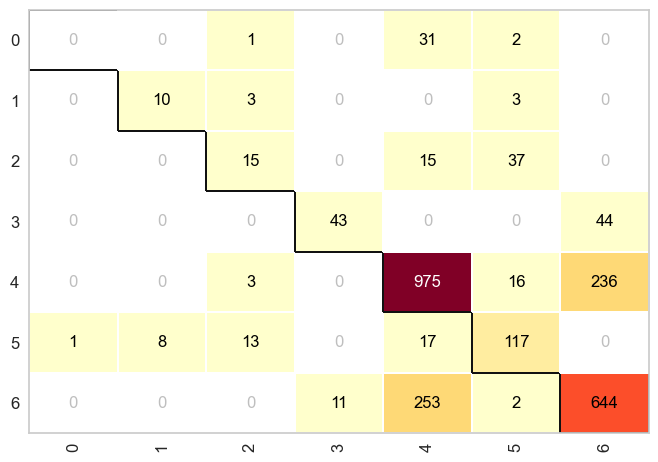

In [32]:
cm = ConfusionMatrix(lr_classifier, force_model=True)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

Exiba o reporte de classificação.

In [ ]:
___